# Module 7: Data Visualisation

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:
- [ ] Create basic plots with Matplotlib (line, bar, scatter, histogram)
- [ ] Build attractive statistical plots with Seaborn
- [ ] Choose the right chart type for your data
- [ ] Customise plots with titles, labels, colours, and legends

**⏱ Estimated Time:** 60–75 minutes  
**📋 Prerequisites:** Modules 1–6 (Python basics, NumPy, Pandas)


## 📦 Environment Setup


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots appear inline in the notebook
%matplotlib inline

# Set a clean default style
plt.rcParams["figure.figsize"] = (8, 5)
sns.set_theme(style="whitegrid")

print("✅ All visualisation libraries loaded!")


✅ All visualisation libraries loaded!


In [19]:
# Helper functions — run once
from IPython.display import HTML, display

def info_box(title, content):
    display(HTML(f"""
    <div style="background:#E3F2FD;padding:15px;border-left:5px solid #2196F3;
    margin:10px 0;border-radius:4px;">
    <strong>💡 {title}</strong><br>{content}</div>"""))

def warning_box(title, content):
    display(HTML(f"""
    <div style="background:#FFF3E0;padding:15px;border-left:5px solid #FF9800;
    margin:10px 0;border-radius:4px;">
    <strong>⚠️ {title}</strong><br>{content}</div>"""))

print("✅ Helpers loaded!")


✅ Helpers loaded!


---
## 📊 Sample Data

We'll use a small dataset throughout this notebook so we can focus on the visualisation, not the data.


In [20]:
# Create sample sales data
np.random.seed(42)
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

sales = pd.DataFrame({
    "month": months,
    "revenue": [12, 15, 13, 17, 20, 22, 25, 24, 21, 19, 23, 28],
    "expenses": [10, 11, 12, 13, 14, 15, 16, 15, 14, 13, 15, 17],
    "region": ["North", "North", "South", "South", "North", "South",
               "North", "South", "North", "South", "North", "South"]
})

# Student exam scores
scores = pd.DataFrame({
    "student": [f"Student_{i}" for i in range(1, 51)],
    "maths": np.random.randint(40, 100, 50),
    "science": np.random.randint(40, 100, 50),
    "english": np.random.randint(40, 100, 50)
})

print("Sales data:")
print(sales.head())
print(f"\nScores data: {scores.shape[0]} students, {scores.shape[1]} columns")


Sales data:
  month  revenue  expenses region
0   Jan       12        10  North
1   Feb       15        11  North
2   Mar       13        12  South
3   Apr       17        13  South
4   May       20        14  North

Scores data: 50 students, 4 columns


---
## 1. Matplotlib — The Foundation

Matplotlib is Python's original plotting library. Every other library (Seaborn, Plotly) is built on top of it.

**Two key objects:**
- `fig` (Figure) — the whole canvas / window
- `ax` (Axes) — the actual plot area where data is drawn


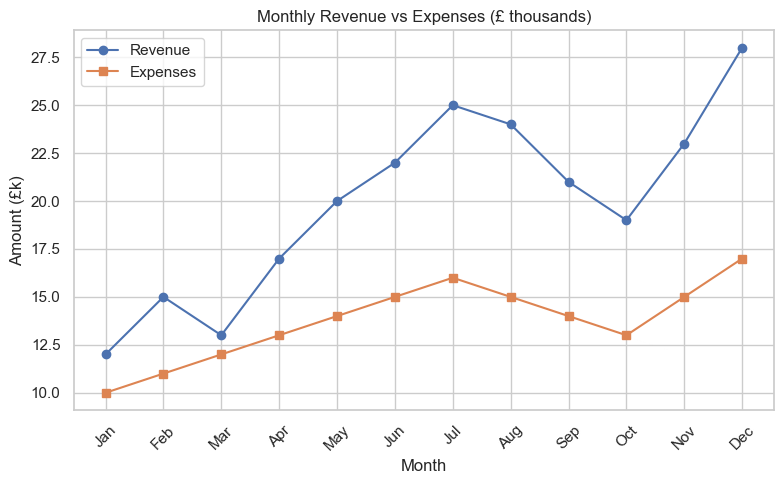

In [21]:
# --- Line Plot ---
fig, ax = plt.subplots()

ax.plot(sales["month"], sales["revenue"], marker="o", label="Revenue")
ax.plot(sales["month"], sales["expenses"], marker="s", label="Expenses")

ax.set_title("Monthly Revenue vs Expenses (£ thousands)")
ax.set_xlabel("Month")
ax.set_ylabel("Amount (£k)")
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


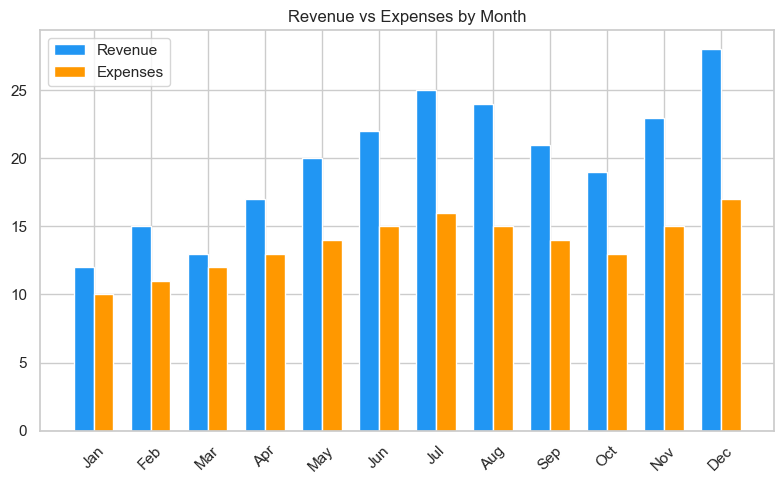

In [33]:
# --- Bar Chart ---
fig, ax = plt.subplots()

x = range(len(sales["month"]))
width = 0.35

ax.bar([i - width/2 for i in x], sales["revenue"], width, label="Revenue", color="#2196F3")
ax.bar([i + width/2 for i in x], sales["expenses"], width, label="Expenses", color="#FF9800")

ax.set_title("Revenue vs Expenses by Month")
ax.set_xticks(x)
ax.set_xticklabels(sales["month"], rotation=45)
ax.legend()

plt.tight_layout()
plt.show()


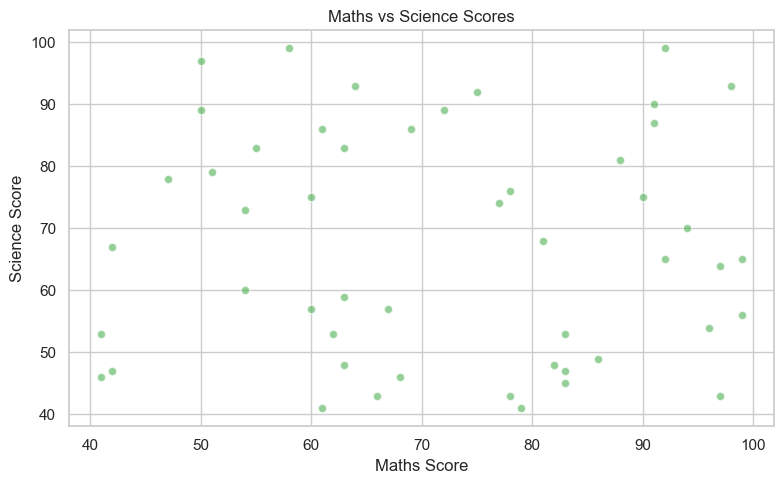

In [34]:
# --- Scatter Plot ---
fig, ax = plt.subplots()

ax.scatter(scores["maths"], scores["science"], alpha=0.6, color="#4CAF50", edgecolors="white")

ax.set_title("Maths vs Science Scores")
ax.set_xlabel("Maths Score")
ax.set_ylabel("Science Score")

plt.tight_layout()
plt.show()


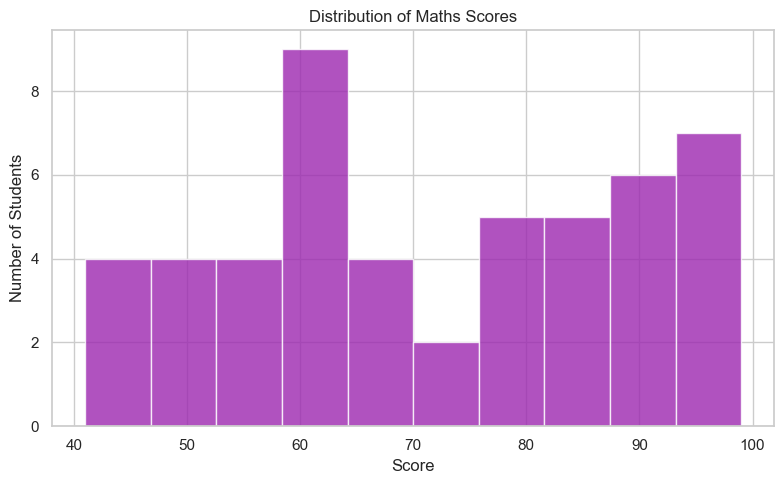

In [24]:
# --- Histogram ---
fig, ax = plt.subplots()

ax.hist(scores["maths"], bins=10, color="#9C27B0", edgecolor="white", alpha=0.8)

ax.set_title("Distribution of Maths Scores")
ax.set_xlabel("Score")
ax.set_ylabel("Number of Students")

plt.tight_layout()
plt.show()


In [25]:
info_box(
    "plt.tight_layout() — Always Use It!",
    "This command adjusts spacing so titles and labels don't get cut off. "
    "Make it a habit to add <code>plt.tight_layout()</code> before <code>plt.show()</code>."
)


---
## 2. Multiple Plots Side by Side (Subplots)

Sometimes you want to compare multiple charts. Use `plt.subplots(rows, cols)` to create a grid.


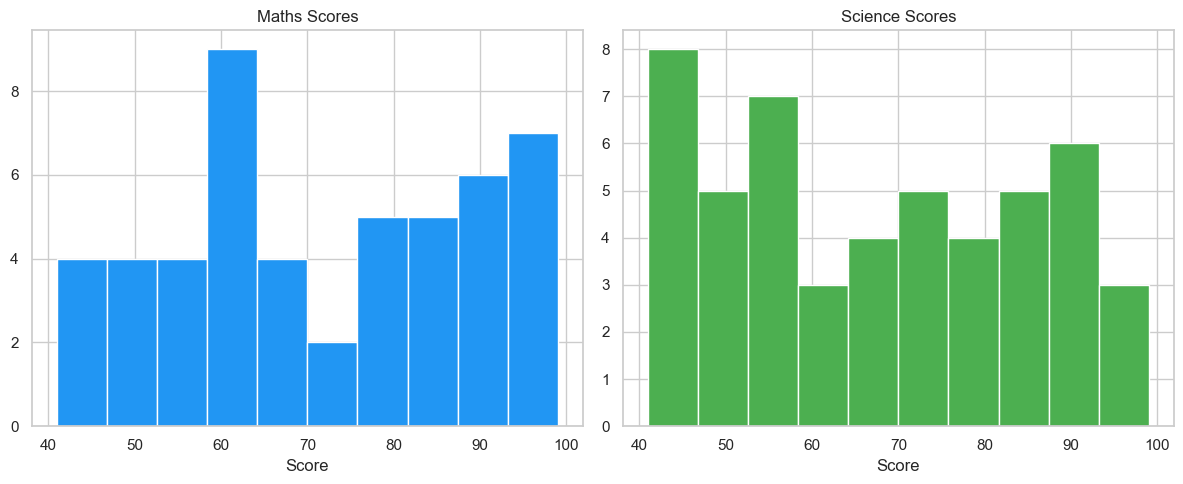

In [35]:
# Two plots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: Histogram of maths scores
ax1.hist(scores["maths"], bins=10, color="#2196F3", edgecolor="white")
ax1.set_title("Maths Scores")
ax1.set_xlabel("Score")

# Right: Histogram of science scores
ax2.hist(scores["science"], bins=10, color="#4CAF50", edgecolor="white")
ax2.set_title("Science Scores")
ax2.set_xlabel("Score")

plt.tight_layout()
plt.show()


---
## 3. Seaborn — Beautiful Statistical Plots

Seaborn sits on top of Matplotlib and makes it much easier to create good-looking statistical charts. It works directly with Pandas DataFrames.


/var/folders/9v/ddnpmp7j6qg_bvv5rxtlm4sw0000gn/T/ipykernel_76476/1060304193.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=scores_long, x="subject", y="score", palette="Set2", ax=ax)


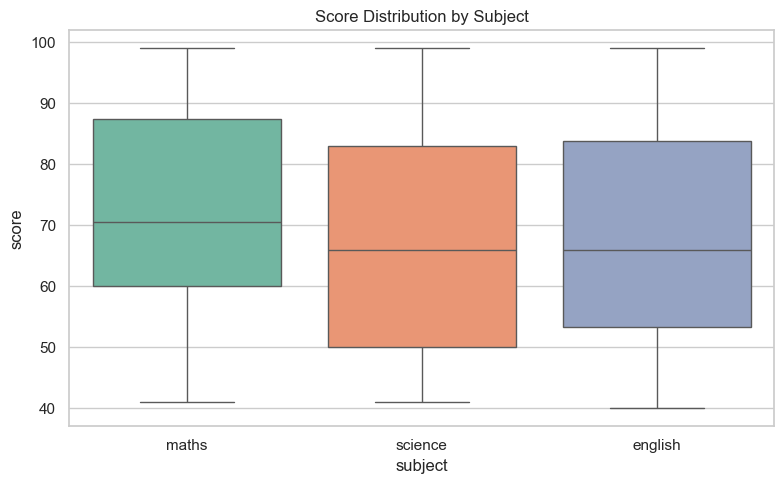

In [36]:
# --- Box Plot: see the spread of each subject ---
fig, ax = plt.subplots(figsize=(8, 5))

# Reshape data for Seaborn (it prefers "long" format)
scores_long = scores.melt(id_vars="student", var_name="subject", value_name="score")

sns.boxplot(data=scores_long, x="subject", y="score", palette="Set2", ax=ax)
ax.set_title("Score Distribution by Subject")

plt.tight_layout()
plt.show()


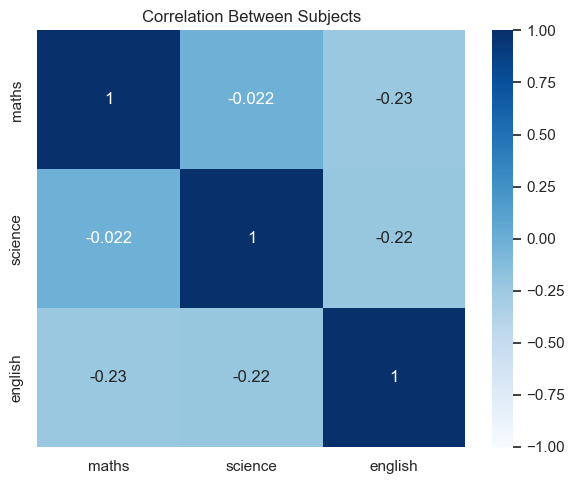

In [37]:
# --- Heatmap: see correlations between subjects ---
fig, ax = plt.subplots(figsize=(6, 5))

corr = scores[["maths", "science", "english"]].corr()
sns.heatmap(corr, annot=True, cmap="Blues", vmin=-1, vmax=1, ax=ax)

ax.set_title("Correlation Between Subjects")
plt.tight_layout()
plt.show()


/var/folders/9v/ddnpmp7j6qg_bvv5rxtlm4sw0000gn/T/ipykernel_76476/4075215713.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=sales, x="region", palette="Set2", ax=ax)


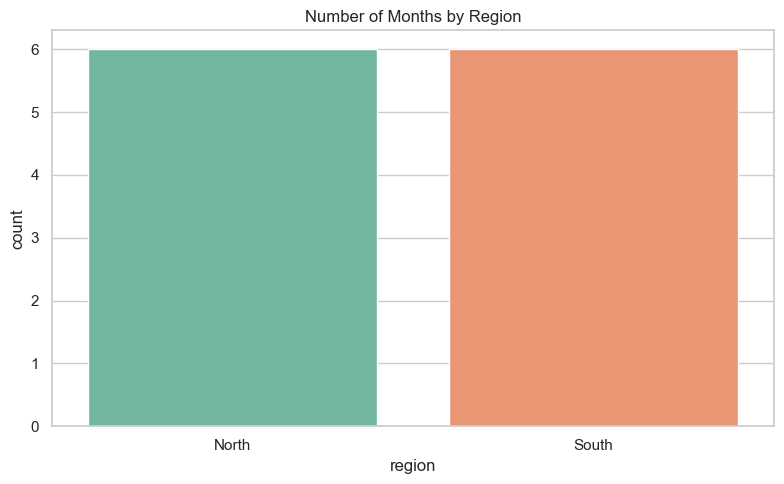

In [38]:
# --- Count Plot: how many months per region ---
fig, ax = plt.subplots()

sns.countplot(data=sales, x="region", palette="Set2", ax=ax)
ax.set_title("Number of Months by Region")

plt.tight_layout()
plt.show()


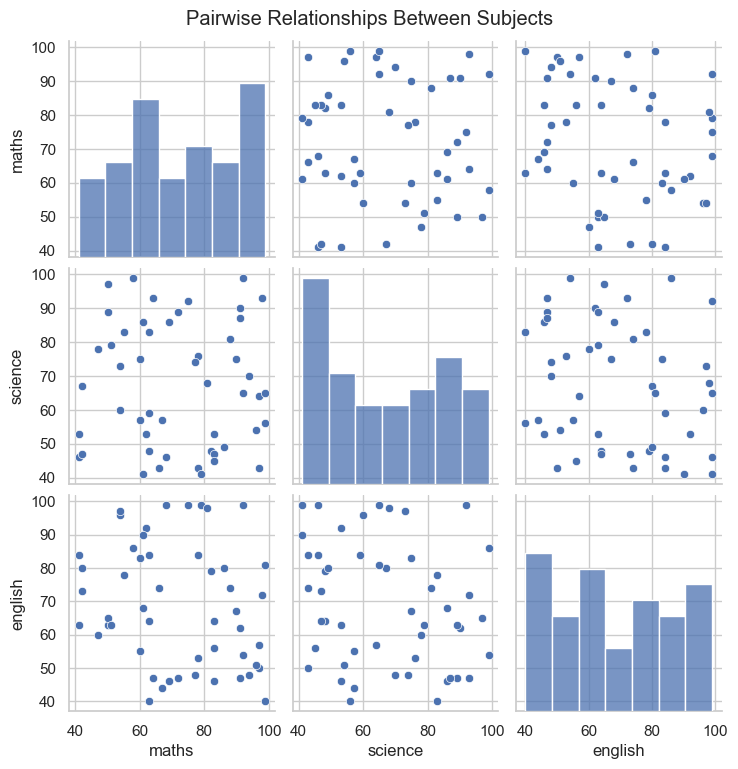

In [30]:
# --- Pairplot: scatter plots of every pair of variables ---
# This is great for quick exploration!
sns.pairplot(scores[["maths", "science", "english"]], diag_kind="hist")
plt.suptitle("Pairwise Relationships Between Subjects", y=1.02)
plt.show()


---
## 4. Choosing the Right Chart

Picking the right chart is just as important as making it look good.

| Your Question | Chart Type | Example |
|-------------|-----------|---------|
| How does something change over time? | **Line plot** | Monthly revenue |
| How do categories compare? | **Bar chart** | Sales by region |
| What's the relationship between two numbers? | **Scatter plot** | Height vs Weight |
| How is the data distributed? | **Histogram** or **Box plot** | Exam score spread |
| What's the proportion? | **Pie chart** (use sparingly!) | Market share |
| How are variables correlated? | **Heatmap** | Feature correlations |


In [31]:
info_box(
    "Rule of Thumb",
    "<b>Comparison</b> → Bar chart<br>"
    "<b>Trend over time</b> → Line chart<br>"
    "<b>Distribution</b> → Histogram or box plot<br>"
    "<b>Relationship</b> → Scatter plot<br>"
    "<b>Composition</b> → Stacked bar or pie chart"
)


---
## 5. Customising Your Plots

A few simple tweaks can make your charts much clearer and more professional.


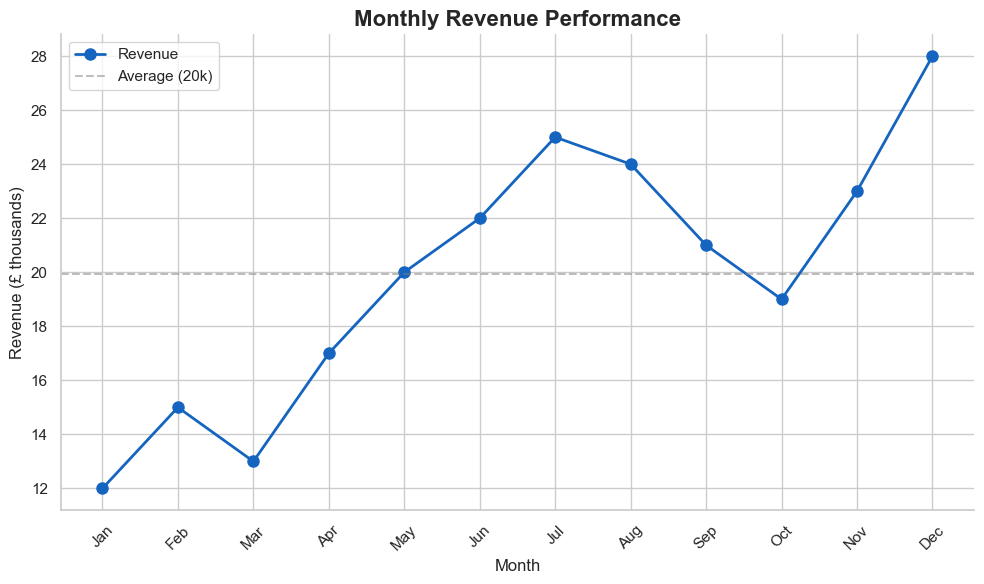

In [32]:
# A well-customised chart
fig, ax = plt.subplots(figsize=(10, 6))

# Plot with custom styling
ax.plot(sales["month"], sales["revenue"], marker="o", color="#1565C0",
        linewidth=2, markersize=8, label="Revenue")

# Add a horizontal reference line
ax.axhline(y=sales["revenue"].mean(), color="gray", linestyle="--",
           alpha=0.5, label=f"Average ({sales['revenue'].mean():.0f}k)")

# Customise appearance
ax.set_title("Monthly Revenue Performance", fontsize=16, fontweight="bold")
ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Revenue (£ thousands)", fontsize=12)
ax.legend(fontsize=11)

# Remove top and right borders for a cleaner look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


---
## 🏋️ Practice Exercises


### Exercise 1: Bar Chart ⭐

Create a bar chart showing the average score per subject (maths, science, english) from the `scores` DataFrame.


In [ ]:
# YOUR CODE HERE




### Exercise 2: Scatter Plot with Colour ⭐⭐

Create a scatter plot of `maths` vs `science` scores. Colour the dots based on whether the `english` score is above or below 70.


In [ ]:
# YOUR CODE HERE
# Hint: Create a new column like scores["english_pass"] = scores["english"] >= 70
# Then use the c= or hue= parameter




### Exercise 3: Side-by-Side Comparison ⭐⭐

Create a figure with 3 subplots (1 row, 3 columns) — one histogram per subject. Give each a different colour and title.


In [ ]:
# YOUR CODE HERE




---
## 📋 Solutions

<details>
<summary>Click to reveal Exercise 1 solution</summary>

```python
fig, ax = plt.subplots()
means = scores[["maths", "science", "english"]].mean()
ax.bar(means.index, means.values, color=["#2196F3", "#4CAF50", "#FF9800"])
ax.set_title("Average Score by Subject")
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()
```

</details>

<details>
<summary>Click to reveal Exercise 2 solution</summary>

```python
fig, ax = plt.subplots()
colours = ["green" if e >= 70 else "red" for e in scores["english"]]
ax.scatter(scores["maths"], scores["science"], c=colours, alpha=0.6, edgecolors="white")
ax.set_title("Maths vs Science (green = English ≥ 70)")
ax.set_xlabel("Maths")
ax.set_ylabel("Science")
plt.tight_layout()
plt.show()
```

</details>

<details>
<summary>Click to reveal Exercise 3 solution</summary>

```python
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
subjects = ["maths", "science", "english"]
colours = ["#2196F3", "#4CAF50", "#FF9800"]
for ax, subj, col in zip(axes, subjects, colours):
    ax.hist(scores[subj], bins=10, color=col, edgecolor="white")
    ax.set_title(f"{subj.title()} Scores")
    ax.set_xlabel("Score")
plt.tight_layout()
plt.show()
```

</details>


---
## 🎯 Key Takeaways

1. **Matplotlib** gives you full control: `fig, ax = plt.subplots()` is the standard pattern.
2. **Seaborn** makes statistical plots (boxplot, heatmap, pairplot) easy and beautiful.
3. **Always** add a title, axis labels, and legend to make your chart understandable.
4. **Choose the right chart** for your question — don't force a pie chart when a bar chart is clearer.
5. **`plt.tight_layout()`** prevents labels from being cut off.

## ✅ Self-Assessment
- [ ] I can create line, bar, scatter, and histogram plots
- [ ] I can use Seaborn for box plots and heatmaps
- [ ] I know which chart type suits different types of data

## 📚 Next Steps
- **Next Module:** Module 8 — Exploratory Data Analysis (EDA)
- **Practice:** Pick a dataset from Kaggle and create 4–5 different charts to explore it
